# IoT Intrusion Detection — Random Forest

This notebook trains and evaluates a **Random Forest** classifier as the next step after the logistic regression baselines.

**Why Random Forest after LR?**

- **Non-linear decision boundaries.** LR can only learn linear separations between classes. RF builds ensembles of deep trees that capture feature interactions (e.g. `syn_flag_number` AND `rate` together predicting a SYN flood) that no linear model can express.
- **Built-in feature importance.** Mean decrease in impurity gives us a ranked list of which network statistics matter most — useful for understanding the dataset and for future feature selection.
- **Robust to scale.** Unlike LR, RF is invariant to feature scaling, so the preprocessed (scaled) input and raw input would give the same splits. We use the preprocessed splits anyway for consistency.
- **Strong ensemble baseline.** RF is a well-understood, hard-to-overfit ensemble. It is a standard step between a linear baseline and gradient-boosted trees.

**What this notebook produces:**

- A fitted `RandomForestClassifier` saved to `models/baseline/random_forest.joblib`.
- A metrics JSON with accuracy, macro-F1, weighted-F1, and per-class precision/recall/F1 for val and test.
- A feature importance bar chart saved to `models/baseline/random_forest_feature_importance.png`.
- Row-normalized confusion matrix PNGs for both splits.

**Primary metric: macro-F1.** Same as LR — accuracy is misleading on this 230:1-imbalanced dataset.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.ensemble import RandomForestClassifier

from src.config import BASELINE_DIR, RANDOM_STATE
from src.data_pipeline import load_artifacts, load_split
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "random_forest"

## 1. Load the preprocessor artifacts and the splits

In [2]:
artifacts = load_artifacts()
X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  _ = load_split("test")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

X_train: (4086646, 47)   y_train: (4086646,)
X_val:   (875710, 47)   y_val:   (875710,)
X_test:  (875710, 47)   y_test:  (875710,)
Classes: 34


## 2. Training data

Random Forest is trained on the **full training split (≈4.1 M rows)**, the same data budget the three-stage classifier in notebook 04 uses. Matching budgets makes the two comparable at the architectural level: any macro-F1 difference between a flat RF and the three-stage hierarchy is then attributable to the decomposition, not to training-set size.

If your machine cannot handle 4 M rows, lower `SUBSAMPLE_FRAC` below 1.0 — the cell handles both cases.

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit

SUBSAMPLE_FRAC = 1.0  # 1.0 = full training split (matches notebook 04). Lower on smaller machines.

if SUBSAMPLE_FRAC >= 1.0:
    X_train_sub = X_train.reset_index(drop=True)
    y_train_sub = y_train.reset_index(drop=True)
else:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=SUBSAMPLE_FRAC, random_state=RANDOM_STATE)
    sub_idx, _ = next(sss.split(X_train, y_train))
    X_train_sub = X_train.iloc[sub_idx].reset_index(drop=True)
    y_train_sub = y_train.iloc[sub_idx].reset_index(drop=True)

print(f"Training rows: {X_train_sub.shape[0]:,} ({SUBSAMPLE_FRAC:.0%} of {X_train.shape[0]:,})")
print(f"Class counts (min/max): {y_train_sub.value_counts().min()} / {y_train_sub.value_counts().max()}")

Training rows: 4,086,646 (100% of 4,086,646)
Class counts (min/max): 876 / 200072


## 3. Configure the model

Key hyperparameters and the reasoning behind each:

- **`n_estimators=200`** — 200 trees. More trees reduce variance and rarely overfit; the main cost is fit time and model size. 200 is a solid default that saturates most of the variance-reduction benefit.
- **`max_features="sqrt"`** — at each split, consider `sqrt(47) ≈ 7` features. The standard classification default. It decorrelates the trees (if all trees saw all features, they'd all make similar splits and cancel less error).
- **`min_samples_leaf=5`** — leaf nodes need at least 5 training rows. Smooths probability estimates for rare classes and caps model size; pure single-row leaves overfit and waste memory.
- **`class_weight="balanced_subsample"`** — recomputes balanced class weights *per bootstrap sample* rather than on the full training set. The RF-specific variant of balanced weighting: each tree sees a slightly different distribution and gets weights calibrated to that bootstrap, which is more statistically correct than one global weight.
- **`oob_score=True`** — each tree is fit on a bootstrap sample (~63% of rows); the remaining ~37% (out-of-bag rows) give a free internal validation estimate without touching the val split. Good sanity check that training is working.
- **`n_jobs=-1`** — builds trees in parallel across all available CPU cores.
- **`random_state=RANDOM_STATE`** — reproducible bootstrap samples and feature subsets.

**Expected fit time:** ~10–20 minutes on 4 M rows, depending on CPU cores. The resulting joblib is large (several GB) because tree depth grows with training data; raise `min_samples_leaf` if model size becomes a problem.

In [4]:
model = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 4. Fit on the training split

In [5]:
with timed(f"Training (RF, 200 trees, {X_train_sub.shape[0]:,} rows)"):
    model.fit(X_train_sub, y_train_sub)

print(f"OOB accuracy:   {model.oob_score_:.4f}  (free internal estimate, not a substitute for val)")
print(f"Train accuracy: {model.score(X_train_sub, y_train_sub):.4f}")

Training (RF, 200 trees, 4,086,646 rows): 443.0s
OOB accuracy:   0.9664  (free internal estimate, not a substitute for val)
Train accuracy: 0.9861


## 5. Evaluate on the validation split

Validation is for **model selection** — comparing RF against LR baselines and choosing whether to invest further. The test set stays untouched until the final step.

In [6]:
val_metrics = evaluate(model, X_val, y_val, artifacts.label_encoder, split_name="val")

print(f"Validation results ({val_metrics.n_rows:,} rows):")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro-F1    = {val_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {val_metrics.weighted_f1:.4f}")

Validation results (875,710 rows):
  accuracy    = 0.9670
  macro-F1    = 0.8607   (primary)
  weighted-F1 = 0.9671


## 6. Per-class report

Sorted by F1 ascending — worst-performing classes first. The rare web/application-layer attacks (`Backdoor_Malware`, `BrowserHijacking`, `SqlInjection`, `XSS`, etc.) cluster at the bottom, motivating the hierarchical approach explored in the next notebook.

In [7]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Recon-PingSweep,0.4639,0.3982,0.4286,339.0000
XSS,0.5466,0.5182,0.5320,577.0000
Backdoor_Malware,0.5083,0.5694,0.5371,483.0000
BrowserHijacking,0.5987,0.5074,0.5493,879.0000
SqlInjection,0.6237,0.5349,0.5759,787.0000
Uploading_Attack,0.6623,0.5319,0.5900,188.0000
DictionaryBruteForce,0.5917,0.6258,0.6083,"1,959.0000"
CommandInjection,0.6321,0.6547,0.6432,811.0000
Recon-OSScan,0.7589,0.7093,0.7333,"14,739.0000"
Recon-PortScan,0.7033,0.7684,0.7344,"12,342.0000"


## 7. Exploratory: BenignTraffic decision-threshold sweep

By default `predict` picks `argmax(proba)` — any class that beats benign by even 0.001 wins. An alternative is to bias decisions toward benign unless the top attack class clearly beats it. Sweeping that margin on the validation set shows the trade-off: lifting macro-F1 slightly sacrifices benign-F1 substantially.

The default threshold is retained: the best-sweep macro-F1 gain (≈ +0.002) does not justify the drop in benign-F1 (≈ -0.10). This cell is kept for transparency; it does not modify the persisted model.

In [8]:
from sklearn.metrics import f1_score

classes = list(model.classes_)
benign_idx = classes.index("BenignTraffic")

# get probabilities on validation set
proba_val = model.predict_proba(X_val)

thresholds = np.arange(0.0, 0.61, 0.05)
results = []

for t in thresholds:
    # predict the argmax class, but override to BenignTraffic if its
    # probability is within `t` of the top class
    top_prob = proba_val.max(axis=1)
    benign_prob = proba_val[:, benign_idx]
    y_pred_t = np.where(
        top_prob - benign_prob <= t,
        "BenignTraffic",
        np.array(classes)[proba_val.argmax(axis=1)],
    )
    macro = f1_score(y_val, y_pred_t, average="macro", zero_division=0)
    benign_f1 = f1_score(y_val, y_pred_t, labels=["BenignTraffic"], average="macro", zero_division=0)
    results.append({"threshold": t, "macro_f1": macro, "benign_f1": benign_f1})

thresh_df = pd.DataFrame(results)
print(thresh_df.to_string(index=False))

best = thresh_df.loc[thresh_df["macro_f1"].idxmax()]
print(f"\nBest threshold by macro-F1: {best['threshold']:.2f}  →  macro-F1={best['macro_f1']:.4f}, benign-F1={best['benign_f1']:.4f}")
BEST_THRESHOLD = best["threshold"]

 threshold  macro_f1  benign_f1
    0.0000    0.8607     0.8833
    0.0500    0.8612     0.8760
    0.1000    0.8625     0.8522
    0.1500    0.8654     0.8115
    0.2000    0.8659     0.7717
    0.2500    0.8614     0.7384
    0.3000    0.8535     0.7076
    0.3500    0.8427     0.6812
    0.4000    0.8298     0.6565
    0.4500    0.8166     0.6329
    0.5000    0.8014     0.6091
    0.5500    0.7856     0.5858
    0.6000    0.7677     0.5652

Best threshold by macro-F1: 0.20  →  macro-F1=0.8659, benign-F1=0.7717


## 8. Feature importance

Mean decrease in impurity (MDI) — how much each feature reduces weighted node impurity across all 200 trees. Higher = more useful split criterion.

Caveat: MDI can overstate the importance of high-cardinality continuous features. A more robust estimator is permutation importance (`sklearn.inspection.permutation_importance`) on the validation set — slower, and skipped here given the size of the validation split.

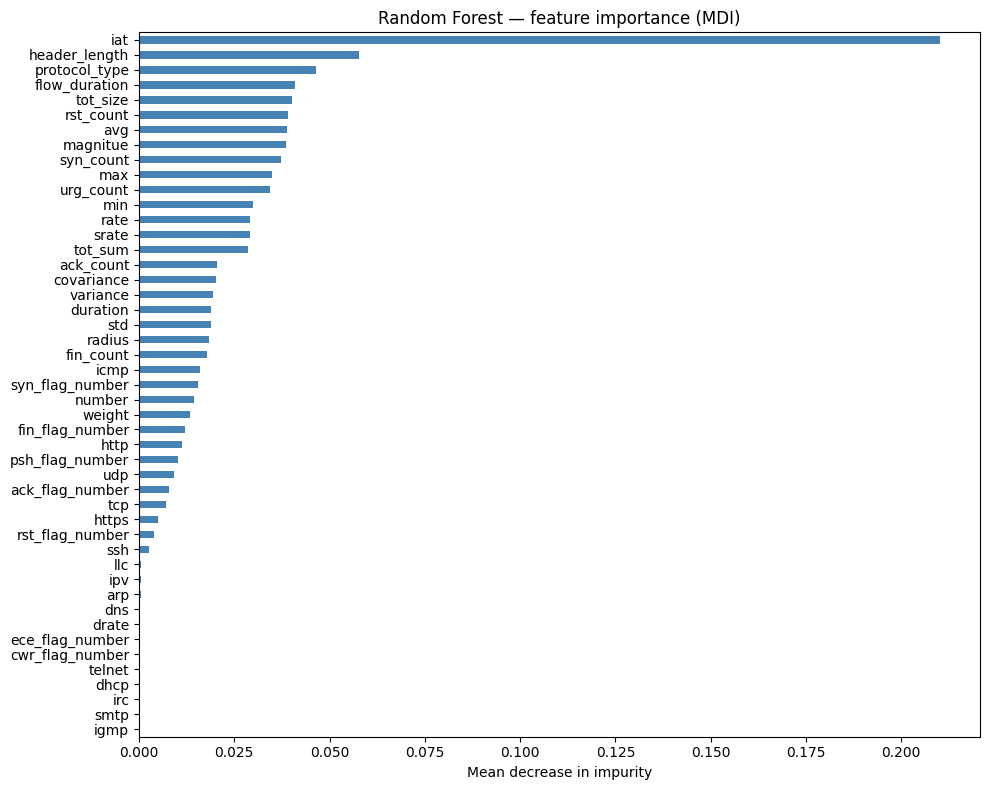


Top 10 features:
               importance
iat                0.2102
header_length      0.0577
protocol_type      0.0465
flow_duration      0.0410
tot_size           0.0401
rst_count          0.0391
avg                0.0387
magnitue           0.0385
syn_count          0.0374
max                0.0350


In [9]:
importance_df = (
    pd.Series(model.feature_importances_, index=X_train_sub.columns)
    .sort_values(ascending=False)
    .rename("importance")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df["importance"].plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest — feature importance (MDI)")
plt.tight_layout()

out_path = BASELINE_DIR / f"{MODEL_NAME}_feature_importance.png"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string())

## 9. Confusion matrix on validation

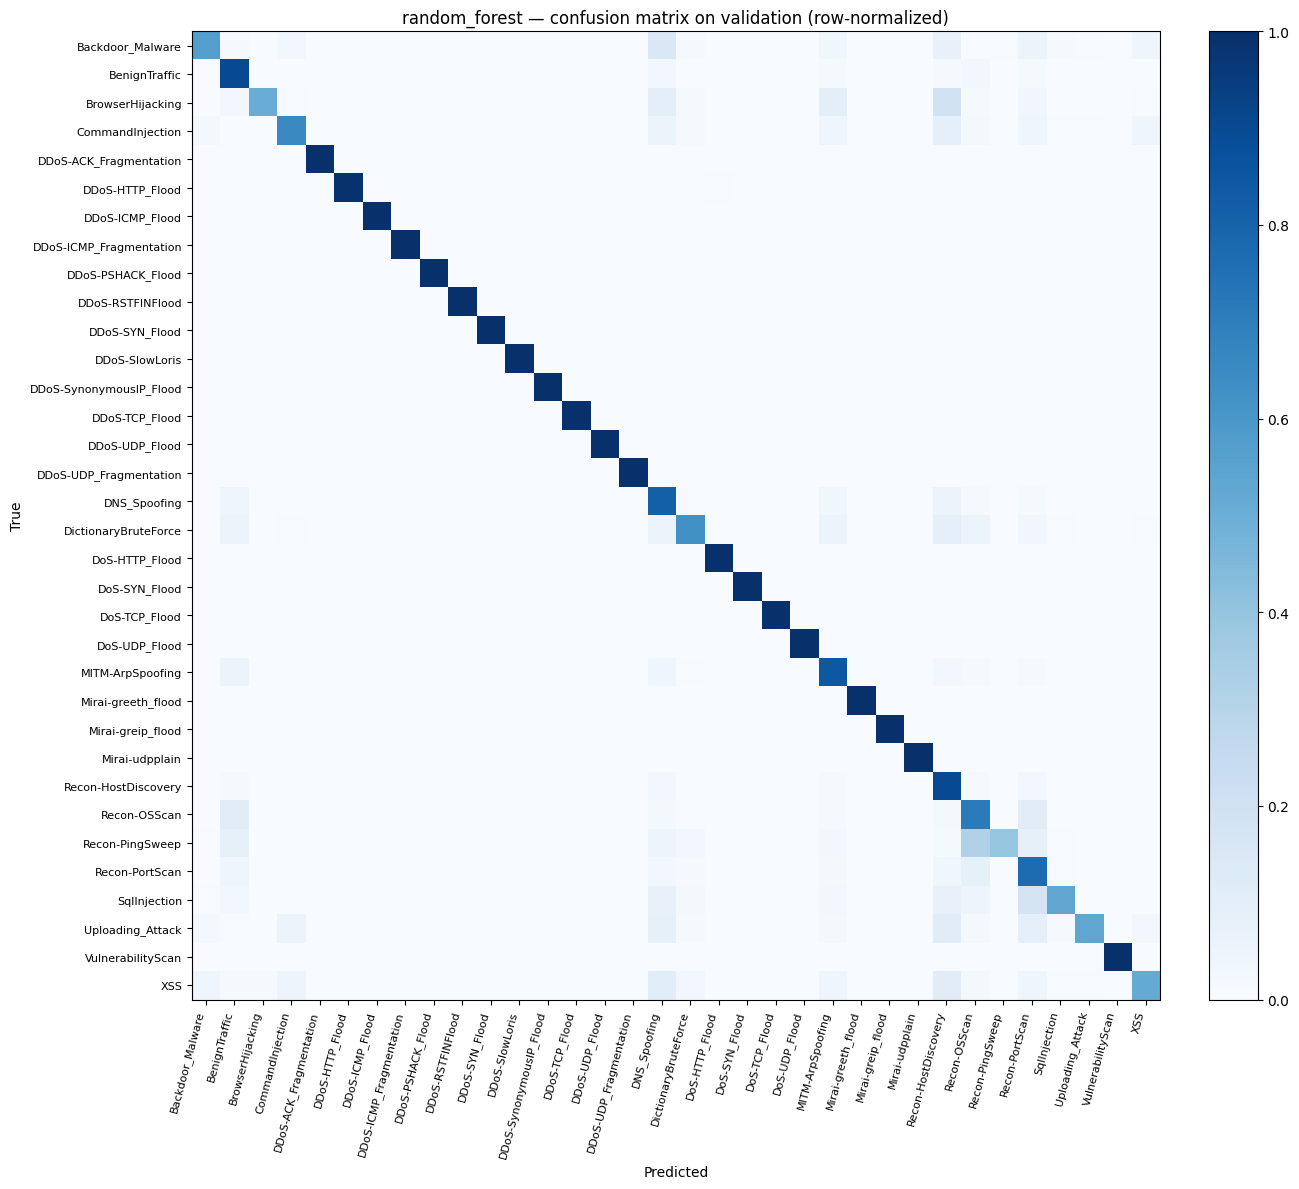

In [10]:
plot_confusion_matrix(
    model, X_val, y_val, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on validation (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 10. Final test-set evaluation

The test split has been held out throughout training and model selection. The numbers below are the unbiased generalisation estimate for this classifier.

In [11]:
test_metrics = evaluate(model, X_test, y_test, artifacts.label_encoder, split_name="test")

print(f"Test results ({test_metrics.n_rows:,} rows):")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro-F1    = {test_metrics.macro_f1:.4f}   (primary)")
print(f"  weighted-F1 = {test_metrics.weighted_f1:.4f}")

print(f"\nval → test macro-F1 delta: {test_metrics.macro_f1 - val_metrics.macro_f1:+.4f}")

Test results (875,710 rows):
  accuracy    = 0.9670
  macro-F1    = 0.8635   (primary)
  weighted-F1 = 0.9671

val → test macro-F1 delta: +0.0028


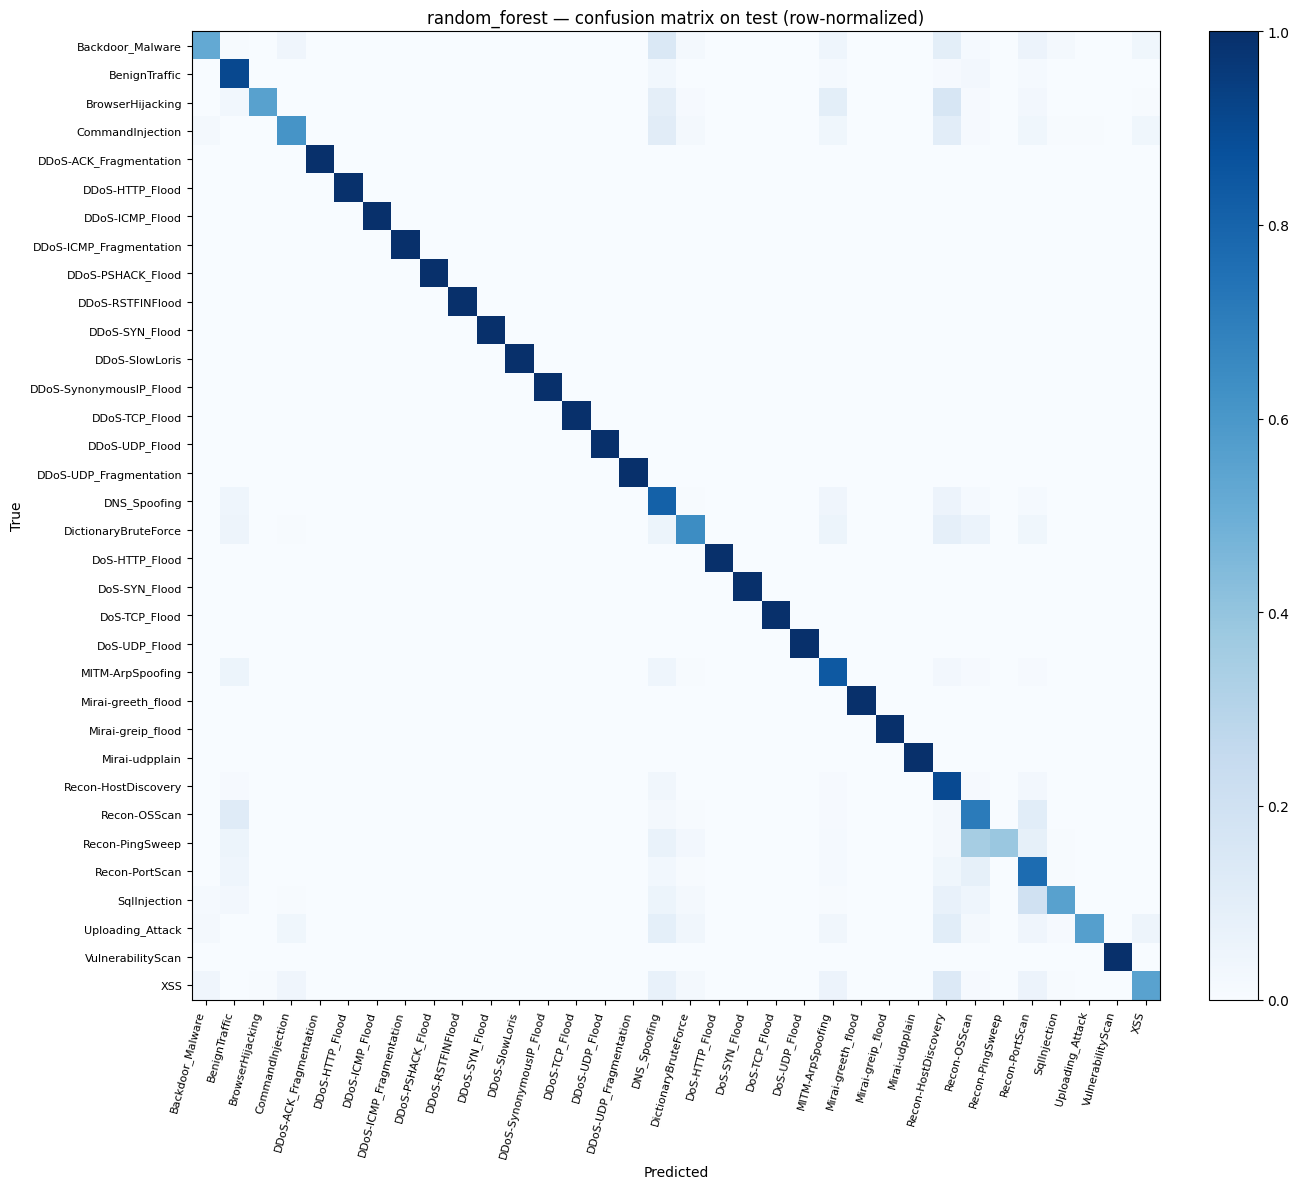

In [12]:
plot_confusion_matrix(
    model, X_test, y_test, artifacts.label_encoder,
    normalize="true",
    title=f"{MODEL_NAME} — confusion matrix on test (row-normalized)",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 11. Persist the model

In [13]:
output_dir = save_baseline(model, [val_metrics, test_metrics], name=MODEL_NAME)

print(f"Saved to {output_dir}:")
for p in sorted(output_dir.glob(f"{MODEL_NAME}*")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name}   ({size_kb:,.1f} KB)")

Saved to C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\models\baseline:
  random_forest.joblib   (7,810,320.4 KB)
  random_forest_confusion_test.png   (164.6 KB)
  random_forest_confusion_val.png   (165.2 KB)
  random_forest_feature_importance.png   (74.3 KB)
  random_forest_metrics.json   (12.8 KB)


## 12. Comparison against the linear baseline

Validation and test metrics side-by-side. Random Forest's large jump in macro-F1 over the linear baseline — driven almost entirely by the rare classes — is the signal that motivated pursuing an even more expressive hierarchical model in the next notebook.

In [17]:
import json

def load_val_metrics(name: str) -> dict:
    path = BASELINE_DIR / f"{name}_metrics.json"
    raw = json.loads(path.read_text())
    # metrics.json is either a list of splits or a single dict
    splits = raw if isinstance(raw, list) else [raw]
    return {m["split"]: m for m in splits}

rows = []
for name in ["logistic_regression", "logistic_regression_v2", MODEL_NAME]:
    path = BASELINE_DIR / f"{name}_metrics.json"
    if not path.exists():
        continue
    splits = load_val_metrics(name)
    for split_name, m in splits.items():
        rows.append({
            "model": name,
            "split": split_name,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "weighted_f1": m["weighted_f1"],
        })

comparison = pd.DataFrame(rows).set_index(["model", "split"])
comparison

accuracy  macro_f1  weighted_f1
model                  split                                 
logistic_regression_v2 val      0.7803    0.5727       0.7878
                       test     0.7800    0.5727       0.7875
random_forest          val      0.9670    0.8607       0.9671
                       test     0.9670    0.8635       0.9671